In [1]:
import pandas as pd

# Загрузка данных
df = pd.read_csv("dating_data.csv")

# Фильтрация по группе 0
group_0 = df[df['group'] == 0]

# Группировка по user_id_1 и расчет метрик
user_stats = group_0.groupby('user_id_1')['is_match'].agg(
    total='count',
    matches='sum'
).reset_index()

# Расчет доли мэтчей с округлением
user_stats['match_rate'] = (user_stats['matches'] / user_stats['total']).round(2)

# Средняя доля
average_match_rate = user_stats['match_rate'].mean()

print(f"Средняя доля мэтчей на пользователя в группе 0: {average_match_rate:}")

Средняя доля мэтчей на пользователя в группе 0: 0.1935928143712575


In [2]:
# Фильтрация по группе 0
group_1 = df[df['group'] == 1]

# Группировка по user_id_1 и расчет метрик
user_stats = group_1.groupby('user_id_1')['is_match'].agg(
    total='count',
    matches='sum'
).reset_index()

# Расчет доли мэтчей с округлением
user_stats['match_rate'] = (user_stats['matches'] / user_stats['total']).round(2)

# Средняя доля
average_match_rate = user_stats['match_rate'].mean()

print(f"Средняя доля мэтчей на пользователя в группе 0: {average_match_rate:}")

Средняя доля мэтчей на пользователя в группе 0: 0.4024048096192385


In [3]:
import pandas as pd
from scipy.stats import mannwhitneyu

# Загрузка данных
df = pd.read_csv("dating_data.csv")

def calculate_group_stats(group_num):
    # Фильтрация и расчет для указанной группы
    group_data = df[df['group'] == group_num]
    user_stats = group_data.groupby('user_id_1')['is_match'].agg(
        total='count',
        matches='sum'
    ).reset_index()
    user_stats['match_rate'] = (user_stats['matches'] / user_stats['total']).round(2)
    return user_stats['match_rate']

# Расчет для обеих групп
group_0_rates = calculate_group_stats(0)
group_1_rates = calculate_group_stats(1)

# Статистика по группам
print(f"Группа 0: Среднее = {group_0_rates.mean():.2f}, STD = {group_0_rates.std():.2f}")
print(f"Группа 1: Среднее = {group_1_rates.mean():.2f}, STD = {group_1_rates.std():.2f}")

# Проведение U-теста
stat, p_value = mannwhitneyu(group_0_rates, group_1_rates, alternative='two-sided')
print(f"\nРезультат U-теста:")
print(f"Статистика = {stat:.2f}, p-значение = {p_value:.4f}")

# Интерпретация
alpha = 0.05
if p_value < alpha:
    print("Есть статистически значимые различия между группами")
else:
    print("Различий между группами не обнаружено")

Группа 0: Среднее = 0.19, STD = 0.13
Группа 1: Среднее = 0.40, STD = 0.11

Результат U-теста:
Статистика = 29753.50, p-значение = 0.0000
Есть статистически значимые различия между группами


In [4]:
import pandas as pd
from scipy import stats
import numpy as np

# Загрузка данных
df = pd.read_csv("dating_data.csv")

def calculate_group_stats(group_num):
    group_data = df[df['group'] == group_num]
    user_stats = group_data.groupby('user_id_1')['is_match'].agg(
        total='count',
        matches='sum'
    ).reset_index()
    user_stats['match_rate'] = (user_stats['matches'] / user_stats['total']).round(2)
    return user_stats['match_rate']

# Расчет для обеих групп
group_0_rates = calculate_group_stats(0)
group_1_rates = calculate_group_stats(1)

# Проверка нормальности распределения
_, p0 = stats.shapiro(group_0_rates)
_, p1 = stats.shapiro(group_1_rates)
print(f"Тест Шапиро-Уилка:\nГруппа 0: p={p0:.4f}\nГруппа 1: p={p1:.4f}")

# Параметрические характеристики
print(f"\nГруппа 0: n={len(group_0_rates)}, М={group_0_rates.mean():.2f}, STD={group_0_rates.std():.2f}")
print(f"Группа 1: n={len(group_1_rates)}, М={group_1_rates.mean():.2f}, STD={group_1_rates.std():.2f}")

# Критерий Уэлча
t_stat, p_value = stats.ttest_ind(
    group_0_rates,
    group_1_rates,
    equal_var=False  # Неравные дисперсии
)

# Интерпретация
alpha = 0.05
print(f"\nt-критерий Уэлча: t({len(group_0_rates)+len(group_1_rates)-2}) = {t_stat:f}, p = {p_value:}")
print("Различия статистически значимы" if p_value < alpha else "Различий не обнаружено")

Тест Шапиро-Уилка:
Группа 0: p=0.0000
Группа 1: p=0.1621

Группа 0: n=501, М=0.19, STD=0.13
Группа 1: n=499, М=0.40, STD=0.11

t-критерий Уэлча: t(998) = -26.481432, p = 7.890669157069948e-117
Различия статистически значимы


In [7]:
# Функция для расчета статистики по группе
def calculate_actions(group_num):
    # Фильтрация по группе
    group_data = df[df['group'] == group_num]
    
    # Подсчет количества взаимодействий на пользователя
    actions_per_user = group_data.groupby('user_id_1').size()
    
    return {
        'mean_actions': round(actions_per_user.mean(), 5),
        'median_actions': actions_per_user.median(),
        'std_actions': round(actions_per_user.std(), 5),
        'total_users': len(actions_per_user),
        'total_actions': actions_per_user.sum()
    }

# Расчет для обеих групп
group_0_stats = calculate_actions(0)
group_1_stats = calculate_actions(1)

# Результаты
print("Группа 0:")
print(f"• Среднее количество действий: {group_0_stats['mean_actions']}")
print(f"• Медиана: {group_0_stats['median_actions']}")
print(f"• STD: {group_0_stats['std_actions']}")
print(f"• Пользователей: {group_0_stats['total_users']}")
print(f"• Всего действий: {group_0_stats['total_actions']}\n")

print("Группа 1:")
print(f"• Среднее количество действий: {group_1_stats['mean_actions']}")
print(f"• Медиана: {group_1_stats['median_actions']}")
print(f"• STD: {group_1_stats['std_actions']}")
print(f"• Пользователей: {group_1_stats['total_users']}")
print(f"• Всего действий: {group_1_stats['total_actions']}")

Группа 0:
• Среднее количество действий: 9.56487
• Медиана: 9.0
• STD: 3.05651
• Пользователей: 501
• Всего действий: 4792

Группа 1:
• Среднее количество действий: 19.48297
• Медиана: 20.0
• STD: 2.99149
• Пользователей: 499
• Всего действий: 9722


In [9]:
import scipy.stats as stats

# Данные группы 0
mean_0 = 9.5648
std_0 = 3.05651
n_0 = 501

# Данные группы 1
mean_1 = 19.4829
std_1 = 2.99149
n_1 = 499

# Расчет t-статистики и p-значения
t_stat, p_value = stats.ttest_ind_from_stats(mean1=mean_0, std1=std_0, nobs1=n_0,
                                             mean2=mean_1, std2=std_1, nobs2=n_1,
                                             equal_var=False)  # Welch's t-test

t_stat, p_value

(-51.85612648648736, 2.003735091003602e-285)

Тест Шапиро-Уилка для группы 0: p-value = 0.00056
Тест Шапиро-Уилка для группы 1: p-value = 0.00003

Тест Левене на равенство дисперсий: p-value = 0.4884

Результаты:
Среднее количество действий в группе 0: 9.56487 ± 3.05651
Среднее количество действий в группе 1: 19.48297 ± 2.99149

t-статистика: -51.85607, p-value: 0.00000


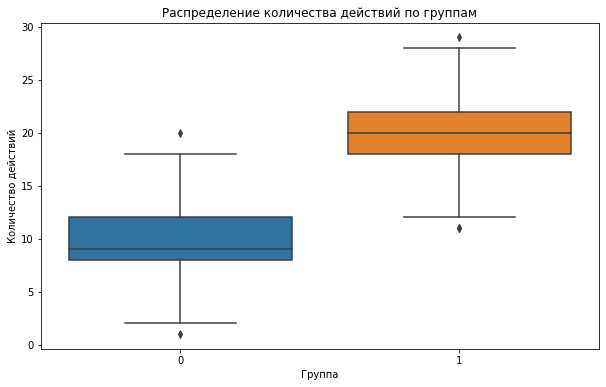


Вывод: Отвергаем нулевую гипотезу - средние количества действий статистически значимо различаются


In [12]:
import pandas as pd
from scipy import stats

# Загрузка данных
df = pd.read_csv("dating_data.csv")

# Считаем количество действий для каждого пользователя в обеих группах
actions_0 = df[df['group'] == 0].groupby('user_id_1').size()
actions_1 = df[df['group'] == 1].groupby('user_id_1').size()

# Проверка нормальности распределения (Шапиро-Уилк)
shapiro_0 = stats.shapiro(actions_0)
shapiro_1 = stats.shapiro(actions_1)

print(f"Тест Шапиро-Уилка для группы 0: p-value = {shapiro_0.pvalue:.5f}")
print(f"Тест Шапиро-Уилка для группы 1: p-value = {shapiro_1.pvalue:.5f}")

# Проверка равенства дисперсий (Левене)
levene_test = stats.levene(actions_0, actions_1)
print(f"\nТест Левене на равенство дисперсий: p-value = {levene_test.pvalue:.4f}")

# Независимый t-тест (двухвыборочный)
t_stat, p_value = stats.ttest_ind(actions_0, actions_1, equal_var=False)  # Welch's t-test

# Альтернатива: классический t-тест с равными дисперсиями
# t_stat, p_value = stats.ttest_ind(actions_0, actions_1, equal_var=True)

import matplotlib.pyplot as plt
import seaborn as sns

print("\nРезультаты:")
print(f"Среднее количество действий в группе 0: {actions_0.mean():.5f} ± {actions_0.std():.5f}")
print(f"Среднее количество действий в группе 1: {actions_1.mean():.5f} ± {actions_1.std():.5f}")
print(f"\nt-статистика: {t_stat:.5f}, p-value: {p_value:.5f}")

# Визуализация распределений
plt.figure(figsize=(10, 6))
sns.boxplot(x='group', y='actions', 
            data=pd.DataFrame({
                'group': ['0']*len(actions_0) + ['1']*len(actions_1),
                'actions': list(actions_0) + list(actions_1)
            }))
plt.title('Распределение количества действий по группам')
plt.ylabel('Количество действий')
plt.xlabel('Группа')
plt.show()

# Интерпретация
alpha = 0.05
if p_value < alpha:
    print("\nВывод: Отвергаем нулевую гипотезу - средние количества действий статистически значимо различаются")
else:
    print("\nВывод: Нет оснований отвергать нулевую гипотезу - значимых различий не обнаружено")